# Decoherence of errors in a single-qubit teleportation chain

## Setting up the code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import qutip as qt
from bounds import get_loose_bounds_on_N, get_tight_bounds_on_N

In [2]:
def set_rcparams():
    from matplotlib import rcParams
    rcParams['figure.figsize'] = 3.375, 2 # PRX single-column width is 3+3/8 inches
    rcParams['lines.linewidth'] = 1 # PRX minimum is 0.5 point, and a point is always 1/72 inch.
    rcParams['lines.markersize'] = 6 # PRX minimum for diameter of datapoint is 1mm (2.83 point)
    rcParams['text.usetex'] = True
    rcParams['font.family'] = 'serif'
    rcParams['font.size'] = 10 # revtex default is 10 pt for 'twocolumn'
set_rcparams()

In [3]:
def get_unitary_channel(theta, unit_vector):
    '''Computes a unitary channel for a qubit
    
    Parameters
    ----------
    theta : float
        rotation angle in radians
    unit_vector : array, shape = (3,)
        a unit_vector indicating the direction of the axis of
        rotation. No need to normalize
    
    Returns
    -------
    unitary_channel : Qobj, dims=[[[2], [2]], [[2], [2]]], shape = (4, 4)
        type = 'super', superrep = 'super'
        the channel corresponding to a unitary rotation.
    '''
    unit_vector = unit_vector / np.linalg.norm(unit_vector)
    axis = unit_vector[0] * qt.sigmax() \
            + unit_vector[1] * qt.sigmay() \
            + unit_vector[2] * qt.sigmaz()
    U_op = (-1j * theta * axis / 2).expm()
    unitary_channel = qt.sprepost(U_op, U_op.dag())
    return unitary_channel

In [4]:
def get_coherent_sequence(error_channels):
    '''Computes the sequence of channels that are obtained
    without teleportation.

    Parameters
    ----------
    
    Returns
    -------
    reference_sequence : list of Qobj, len = n_max + 1, 
        dims=[[[2], [2]], [[2], [2]]], type='super'
        The untwirled sequence of channels, starting with identity
    '''
    I = qt.spre(qt.identity(2)) # identity channel
    reference_sequence = [I]
    for error_channel in error_channels:
        reference_sequence.append(
            error_channel * reference_sequence[-1])
    return reference_sequence


def get_rc_sequence(error_channels):
    '''Computes the sequence of channels that are obtained
    without teleportation.

    Parameters
    ----------
    
    Returns
    -------
    pta_sequence : list of Qobj, len = n_max + 1, 
        dims=[[[2], [2]], [[2], [2]]], type='super'
        The untwirled sequence of channels, starting with identity
    '''
    def twirl_channel(input_channel):
        X = qt.sprepost(qt.sigmax(), qt.sigmax())
        Z = qt.sprepost(qt.sigmaz(), qt.sigmaz())
        output_channel = input_channel
        output_channel = 0.5 * (output_channel + Z * output_channel * Z)
        output_channel = 0.5 * (output_channel + X * output_channel * X)
        return output_channel
    I = qt.spre(qt.identity(2)) # identity channel
    pta_sequence = [I]
    for error_channel in error_channels:
        pta_sequence.append(
            twirl_channel(error_channel) * pta_sequence[-1])
    return pta_sequence


def get_teleported_sequence(error_channels):
    # define Pauli channels
    I = qt.spre(qt.identity(2))
    X = qt.sprepost(qt.sigmax(), qt.sigmax())
    Y = qt.sprepost(qt.sigmay(), qt.sigmay())
    Z = qt.sprepost(qt.sigmaz(), qt.sigmaz())
    H = qt.Qobj(np.array([[1, 1], [1, -1]]) / np.sqrt(2))
    H = qt.sprepost(H, H)

    # initialize the conditional_channel 
    cond_channels = []
    channels = [I]
    
    if len(error_channels) >= 1:
        error_channel = error_channels[0]
        cond_channels = {'H': H * error_channel * H,
                         'HZ': (Z * H) * error_channel * (H * Z)}
        channels.append((cond_channels['H'] + cond_channels['HZ']) / 2)
    
    if len(error_channels) >= 2:
        error_channel = error_channels[1]
        cond_channels = {'I': I * error_channel * I * cond_channels['H'],
                         'X': X * error_channel * X * cond_channels['H'],
                         'Z': Z * error_channel * Z * cond_channels['HZ'],
                         'Y': Y * error_channel * Y * cond_channels['HZ']}
        channels.append((cond_channels['I'] + cond_channels['X'] + cond_channels['Y'] + cond_channels['Z']) / 4)

    for t in range(3, len(error_channels) + 1):
        error_channel = error_channels[t - 1] # the time step is one more than the index

        # compute the conjugated error channels
        # conj_channels[b_t][b_t-1] is the error channel conjugated
        # by appropriate paulis
        if t % 2 == 1: # odd time step
            cond_channels = {'H': 0.5 * H * error_channel * H * (cond_channels['I']  + cond_channels['Z']),
                            'HZ': 0.5 * (Z * H) * error_channel * (H * Z) * (cond_channels['I'] + cond_channels['Z']),
                            'HX': 0.5 * (X * H) * error_channel * (H * X) * (cond_channels['X'] + cond_channels['Y']),
                            'HY': 0.5 * (Y * H) * error_channel * (H * Y) * (cond_channels['X'] + cond_channels['Y']),}
            channels.append((cond_channels['H'] + cond_channels['HX'] + cond_channels['HY'] + cond_channels['HZ']) / 4)
        else: # even time step
            cond_channels = {'I': 0.5 * I * error_channel * I * (cond_channels['H'] + cond_channels['HX']),
                            'X': 0.5 * X * error_channel * X * (cond_channels['H'] + cond_channels['HX']),
                            'Z': 0.5 * Z * error_channel * Z * (cond_channels['HZ'] + cond_channels['HY']),
                            'Y': 0.5 * Y * error_channel * Y * (cond_channels['HZ'] + cond_channels['HY']),}
            channels.append((cond_channels['I'] + cond_channels['X'] + cond_channels['Y'] + cond_channels['Z']) / 4)
    return channels

## Begin plotting

### Analytical bounds plot

In [5]:
def make_plot_analytical_bounds(error_channels, ylim=(0, 0.5), filename='bounds.pdf',
                                show_inset=False, show_legend=False,
                                inset_xmin=18, inset_xmax=20, inset_ymin=0.03, inset_ymax=0.04):
    # note the factor of 2.
    T = len(error_channels)
    time = np.arange(T + 1)

    def channel_to_ptm(channels):
        e_ops = [qt.qeye(2), qt.sigmax(), qt.sigmay(), qt.sigmaz()]
        expectation = np.array([[[qt.expect(output, ch(input)) / 2 for input in e_ops] for output in e_ops] for ch in channels])
        return expectation
    coherent_sequence = get_coherent_sequence(error_channels) # compute untwirled average error channels
    rc_sequence = get_rc_sequence(error_channels) # compute average error channels under randomized compiling
    teleported_sequence = get_teleported_sequence(error_channels) # compute average error channels under teleportation

    looser_bounds = get_loose_bounds_on_N(error_channels) # compute analytical bounds
    P_lower_looser, P_upper_looser = looser_bounds[:,:,0], looser_bounds[:,:,1]

    tighter_bounds = get_tight_bounds_on_N(error_channels) # compute analytical bounds
    P_lower_tighter, P_upper_tighter = tighter_bounds[:,:,0], tighter_bounds[:,:,1]

    #############
    # PLOTTTING #
    #############
    fig, ax = plt.subplots(1, 1, figsize=(6.75/2, 2), dpi=300)

    ax.plot(time, 0.5 - (channel_to_ptm(coherent_sequence)[:, 1, 1] \
                        + channel_to_ptm(coherent_sequence)[:, 2, 2] \
                        + channel_to_ptm(coherent_sequence)[:, 3, 3]) / 6,
            '-x', color='#707070',
            label='coherent', ms=4)
    
    ax.plot(time, 0.5 - (channel_to_ptm(rc_sequence)[:, 1, 1] \
                        + channel_to_ptm(rc_sequence)[:, 2, 2] \
                        + channel_to_ptm(rc_sequence)[:, 3, 3]) / 6, '-o', color='#378821',
            label='rand. comp.', ms=2)
    
    ax.plot(time, 0.5 - (channel_to_ptm(teleported_sequence)[:, 1, 1] \
                        + channel_to_ptm(teleported_sequence)[:, 2, 2] \
                        + channel_to_ptm(teleported_sequence)[:, 3, 3]) / 6, '-^',
            color='#000000', lw=1, label='teleportation', ms=3)
    
    # plot looser analytical bounds
    ax.fill_between(time,
                    0.5 - (P_lower_looser[:, 1] + P_lower_looser[:, 2] + P_lower_looser[:, 3]) / 6,
                    0.5 - (P_upper_looser[:, 1] + P_upper_looser[:, 2] + P_upper_looser[:, 3]) / 6,
                    facecolor='#F2A93B',#'#A0A0FF',
                    alpha=0.3,
                    label='2$^{\mathrm{nd}}\,$order bounds', lw=1)
    
    # plot tighter analytical bounds
    ax.fill_between(time,
                    0.5 - (P_lower_tighter[:, 1] + P_lower_tighter[:, 2] + P_lower_tighter[:, 3]) / 6,
                    0.5 - (P_upper_tighter[:, 1] + P_upper_tighter[:, 2] + P_upper_tighter[:, 3]) / 6,
                    facecolor='#F2A93B',#'#A0A0FF',
                    label='3$^{\mathrm{rd}}\,$order bounds', lw=0)

    if show_legend:
        ax.legend(handlelength=0.8, handletextpad=0.2, labelspacing=0.05, loc='upper right',
                fontsize=9, ncol=1, columnspacing=0.35)
    ax.set_xlim(0, T+0.001)
    ax.set_ylim(*ylim)
    ax.set_xlabel('Total number of time steps, $T$')
    ax.set_ylabel(f'Average infidelity')
    #ax.set_title('$e^{i(\\theta_x X + \\theta_y Y + \\theta_z Z)}$, ' \
    #             + '$\\vec{\\theta} = {' \
    #            + f'\langle{theta[0]}, {theta[1]}, {theta[2]}\\rangle' + '}$', fontsize=8)

    if show_inset:
        
        # These are in unitless percentages of the figure size. (0,0 is bottom left)
        left, bottom, width, height = [0.70, 0.7, 0.2, 0.2]
        ax2 = fig.add_axes([left, bottom, width, height])
        ax2.plot(time, 0.5 - (channel_to_ptm(teleported_sequence)[:, 1, 1] \
                        + channel_to_ptm(teleported_sequence)[:, 2, 2] \
                        + channel_to_ptm(teleported_sequence)[:, 3, 3]) / 6, '-^',
            color='#000000', lw=1, label='teleportation', ms=3)
    
        # plot looser analytical bounds
        ax2.fill_between(time,
                        0.5 - (P_lower_looser[:, 1] + P_lower_looser[:, 2] + P_lower_looser[:, 3]) / 6,
                        0.5 - (P_upper_looser[:, 1] + P_upper_looser[:, 2] + P_upper_looser[:, 3]) / 6,
                        facecolor='#F2A93B',#'#A0A0FF',
                        alpha=0.3,
                        label='2$^{\mathrm{nd}}\,$order bounds', lw=1)
        
        # plot tighter analytical bounds
        ax2.fill_between(time,
                        0.5 - (P_lower_tighter[:, 1] + P_lower_tighter[:, 2] + P_lower_tighter[:, 3]) / 6,
                        0.5 - (P_upper_tighter[:, 1] + P_upper_tighter[:, 2] + P_upper_tighter[:, 3]) / 6,
                        facecolor='#F2A93B',#'#A0A0FF',
                        label='3$^{\mathrm{rd}}\,$order bounds', lw=0)
        ax2.set_xlim(inset_xmin, inset_xmax)
        ax2.set_ylim(inset_ymin, inset_ymax)

        # Create a Rectangle patch
        rect = patches.Rectangle((inset_xmin, inset_ymin), inset_xmax - inset_xmin, inset_ymax - inset_ymin,
                                 linewidth=0.8, edgecolor='r', facecolor='none', zorder=100)

        # Add the patch to the Axes
        ax.add_patch(rect)


    fig.subplots_adjust(left=0.17, right=0.96, top=0.97, bottom=0.21)
    fig.savefig(filename)
    return


## Show change in uncertainty with $\epsilon$

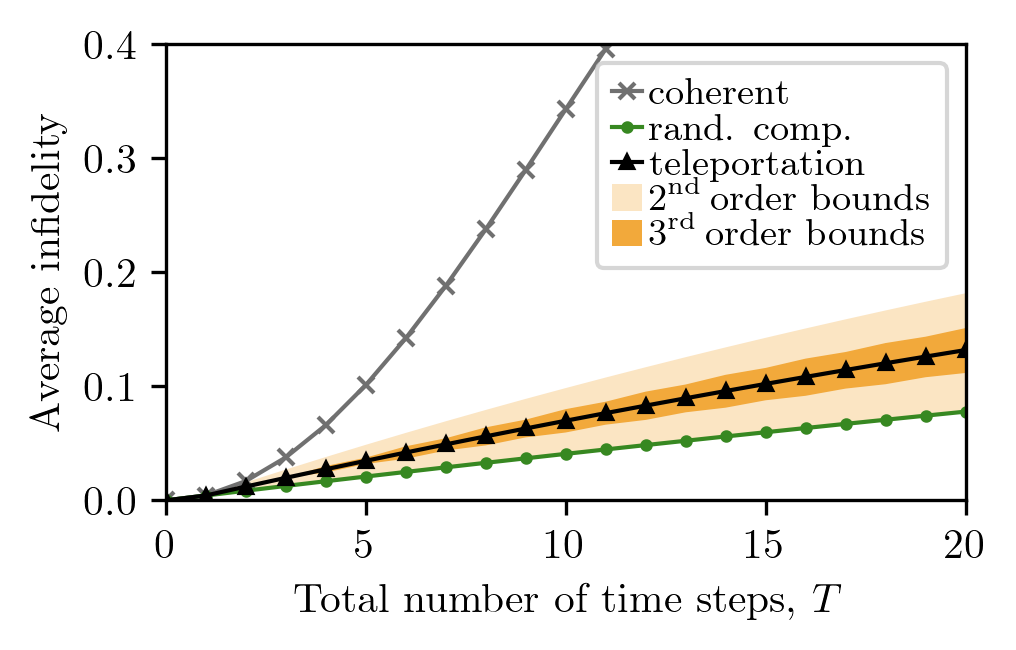

In [6]:
theta = np.array([3, 1, 2]) / np.sqrt(14) * 0.08
T = 20
error_channels = [get_unitary_channel(
    theta=2 * np.linalg.norm(theta), unit_vector=theta)] * T
make_plot_analytical_bounds(error_channels, ylim=(0, 0.4), filename='fig2a.pdf', show_legend=True)

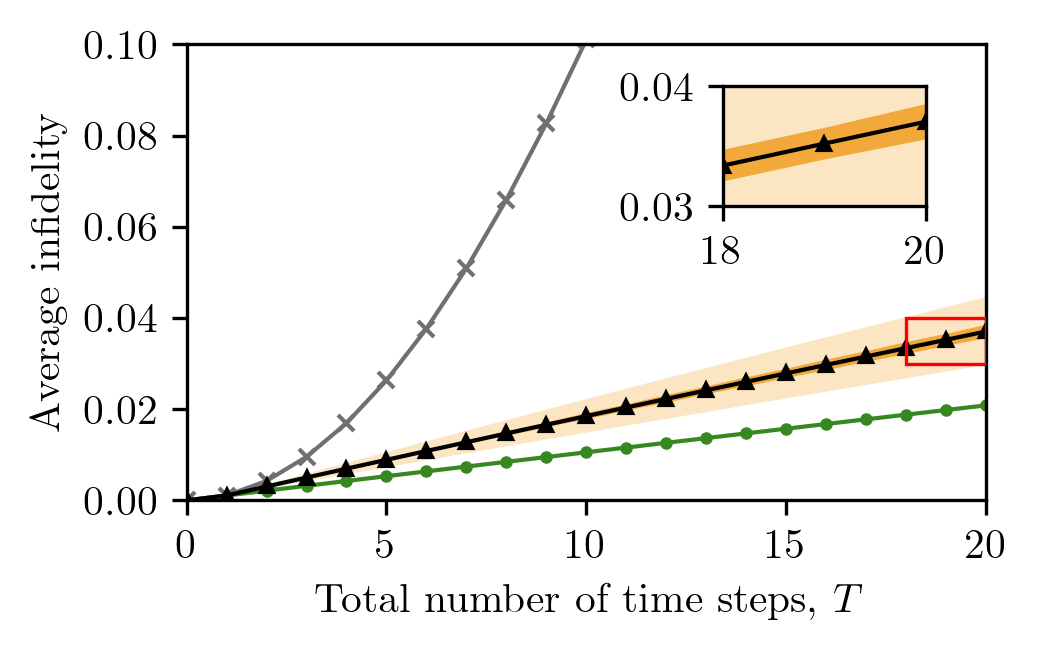

In [7]:
theta = np.array([3, 1, 2]) / np.sqrt(14) * 0.04
T = 20
error_channels = [get_unitary_channel(
    theta=2 * np.linalg.norm(theta), unit_vector=theta)] * T
make_plot_analytical_bounds(error_channels, ylim=(0, 0.1), filename='fig2b.pdf',
                            show_inset=True, show_legend=False,
                            inset_xmin=18, inset_xmax=20,
                            inset_ymin=0.03, inset_ymax=0.04)